In [3]:
import json
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from langdetect import detect
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "app").exists():
    PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from app.core.config import settings
from app.services.preprocessing.pii_cleaner import (
    CARD_PATTERN,
    EMAIL_PATTERN,
    IPV4_PATTERN,
    PHONE_PATTERN,
)

plt.style.use("seaborn-v0_8-whitegrid")


# Section 1 — Load corpus

In [4]:
corpus_path = PROJECT_ROOT / "data" / "corpus.jsonl"
records = []

with corpus_path.open("r", encoding="utf-8") as file:
    for line in file:
        item = json.loads(line)
        metadata = item.get("metadata", {})
        records.append({"text": item.get("text", ""), **metadata})

df = pd.DataFrame(records)
for column in ["text", "source", "page_number", "chunk_index"]:
    if column not in df.columns:
        df[column] = None

print(f"Total chunks loaded: {len(df)}")
print(f"Unique sources found: {df['source'].nunique()}")
df.head()


Total chunks loaded: 7
Unique sources found: 1


,text,source,page_number,chunk_index
0,Y IT-RANKS EGYPT Overtime Policy For IT-RANKS ...,pdfs\Overtime Policy v1.3.pdf,1,0
1,Overtime Policy IT-RANKS Egypt recognizes that...,pdfs\Overtime Policy v1.3.pdf,2,0
2,and subsequently reviewed by the Resource Mana...,pdfs\Overtime Policy v1.3.pdf,2,1
3,Egyptian labor law. o As per the Egyptian labo...,pdfs\Overtime Policy v1.3.pdf,2,2
4,"o If an employee is called out, he will be ent...",pdfs\Overtime Policy v1.3.pdf,3,0


# Section 2 — Corpus overview

Total chunks: 7
Unique source files: 1
Average chunks per source: 7.00


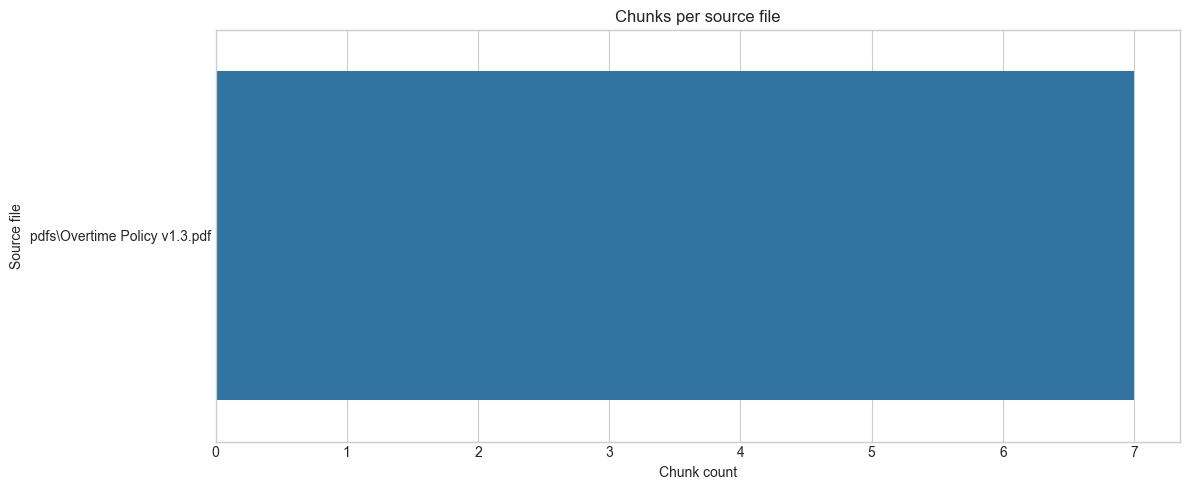

In [5]:
total_chunks = len(df)
unique_sources = df["source"].nunique()
avg_chunks_per_source = total_chunks / unique_sources if unique_sources else 0

print(f"Total chunks: {total_chunks}")
print(f"Unique source files: {unique_sources}")
print(f"Average chunks per source: {avg_chunks_per_source:.2f}")

chunks_per_source = df.groupby("source").size().sort_values(ascending=False)
plt.figure(figsize=(12, 5))
sns.barplot(x=chunks_per_source.values, y=chunks_per_source.index, orient="h")
plt.title("Chunks per source file")
plt.xlabel("Chunk count")
plt.ylabel("Source file")
plt.tight_layout()
plt.show()


# Section 3 — Chunk length distribution

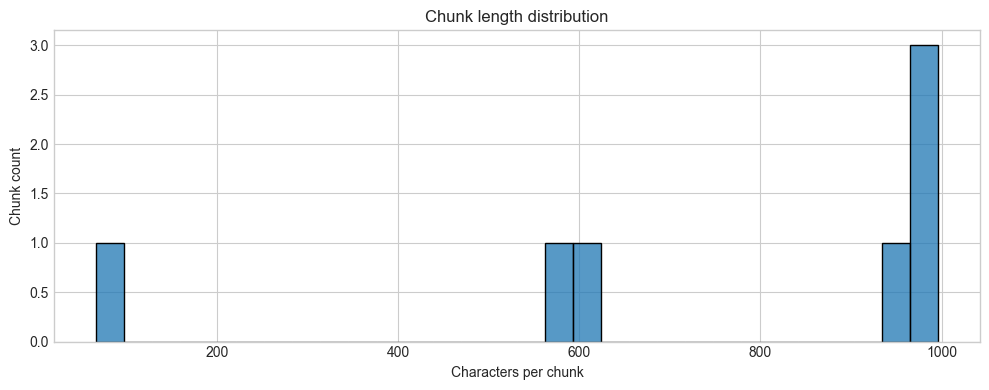

Min: 66
Max: 996
Mean: 736.00
Median: 960.00
P5: 217.20
P95: 991.80
Outlier chunks: 1


In [6]:
df["char_count"] = df["text"].fillna("").str.len()

plt.figure(figsize=(10, 4))
sns.histplot(df["char_count"], bins=30)
plt.title("Chunk length distribution")
plt.xlabel("Characters per chunk")
plt.ylabel("Chunk count")
plt.tight_layout()
plt.show()

stats = df["char_count"].describe(percentiles=[0.05, 0.5, 0.95])
print(f"Min: {stats['min']:.0f}")
print(f"Max: {stats['max']:.0f}")
print(f"Mean: {stats['mean']:.2f}")
print(f"Median: {stats['50%']:.2f}")
print(f"P5: {stats['5%']:.2f}")
print(f"P95: {stats['95%']:.2f}")

outlier_mask = (df["char_count"] < 100) | (df["char_count"] > settings.CHUNK_SIZE * 1.5)
print(f"Outlier chunks: {int(outlier_mask.sum())}")


# Section 4 — Top terms by source type

In [7]:
df["source_ext"] = df["source"].fillna("").apply(lambda value: Path(str(value)).suffix.lower() or "unknown")

for source_ext, group in df.groupby("source_ext"):
    texts = group["text"].fillna("").tolist()
    if not any(text.strip() for text in texts):
        continue
    vectorizer = TfidfVectorizer(stop_words="english", max_features=5000)
    matrix = vectorizer.fit_transform(texts)
    scores = matrix.mean(axis=0).A1
    terms = vectorizer.get_feature_names_out()
    top_indices = scores.argsort()[::-1][:20]
    top_terms = pd.DataFrame({"term": terms[top_indices], "score": scores[top_indices]})
    print(f"Top terms for {source_ext}")
    display(top_terms)


Top terms for .pdf


,term,score
0,overtime,0.246225
1,hours,0.160709
2,employees,0.112631
3,ranks,0.110897
4,policy,0.090951
5,00,0.086040
6,shift,0.080708
7,work,0.074628
8,hourly,0.074096
9,labor,0.073683


# Section 5 — Topic modeling

Topic 1: policy, month, employees, required, reviewed, ensure, regulations, compliance, calculated, submit
Topic 2: ranks, egypt, policy, required, compensation, approval, employee, follows, project, holiday
Topic 3: approval, manager, work, employees, project, worked, approved, month, email, lieu
Topic 4: ranks, egypt, policy, required, compensation, approval, employee, follows, project, holiday
Topic 5: hours, hourly, labor, rate, 00, pm, rates, pay, number, egyptian
Topic 6: ranks, egypt, policy, required, compensation, approval, employee, follows, project, holiday
Topic 7: employees, compensation, additional, 00, time, lieu, follows, public, egypt, request
Topic 8: hours, work, ranks, policy, project, 50, exceed, needs, regular, resource


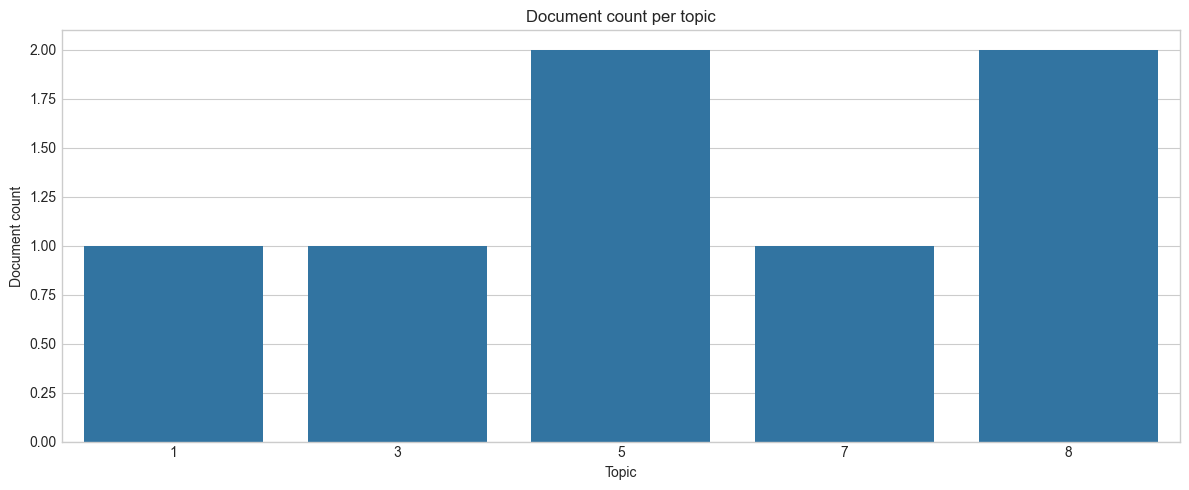

In [8]:
texts = df["text"].fillna("").tolist()
count_vectorizer = CountVectorizer(stop_words="english", max_df=0.95, min_df=2, max_features=5000)
term_matrix = count_vectorizer.fit_transform(texts)
lda = LatentDirichletAllocation(n_components=8, random_state=42)
topic_matrix = lda.fit_transform(term_matrix)
feature_names = count_vectorizer.get_feature_names_out()

for topic_index, topic in enumerate(lda.components_, start=1):
    top_indices = topic.argsort()[::-1][:10]
    keywords = ", ".join(feature_names[index] for index in top_indices)
    print(f"Topic {topic_index}: {keywords}")

df["topic"] = topic_matrix.argmax(axis=1) + 1
topic_counts = df["topic"].value_counts().sort_index()
plt.figure(figsize=(12, 5))
sns.barplot(x=topic_counts.index, y=topic_counts.values)
plt.title("Document count per topic")
plt.xlabel("Topic")
plt.ylabel("Document count")
plt.tight_layout()
plt.show()


# Section 6 — PII and noise report

In [9]:
placeholder_pattern = re.compile(r"\[(?:EMAIL|PHONE|CARD|IP)\]")
pii_placeholder_mask = df["text"].fillna("").str.contains(placeholder_pattern)
placeholder_count = int(pii_placeholder_mask.sum())
placeholder_percentage = (placeholder_count / len(df) * 100) if len(df) else 0

print(f"Chunks with at least one PII placeholder: {placeholder_count}")
print(f"Percentage of total corpus: {placeholder_percentage:.2f}%")

empty_chunk_count = int(df["text"].fillna("").str.strip().str.len().lt(10).sum())
print(f"Empty chunk count: {empty_chunk_count}")

pattern_report = {
    "email_placeholders": int(df["text"].fillna("").str.contains("[EMAIL]", regex=False).sum()),
    "phone_placeholders": int(df["text"].fillna("").str.contains("[PHONE]", regex=False).sum()),
    "card_placeholders": int(df["text"].fillna("").str.contains("[CARD]", regex=False).sum()),
    "ip_placeholders": int(df["text"].fillna("").str.contains("[IP]", regex=False).sum()),
}
pd.Series(pattern_report).to_frame("chunk_count")


Chunks with at least one PII placeholder: 0
Percentage of total corpus: 0.00%
Empty chunk count: 0


,chunk_count
email_placeholders,0
phone_placeholders,0
card_placeholders,0
ip_placeholders,0


# Section 7 — Language detection

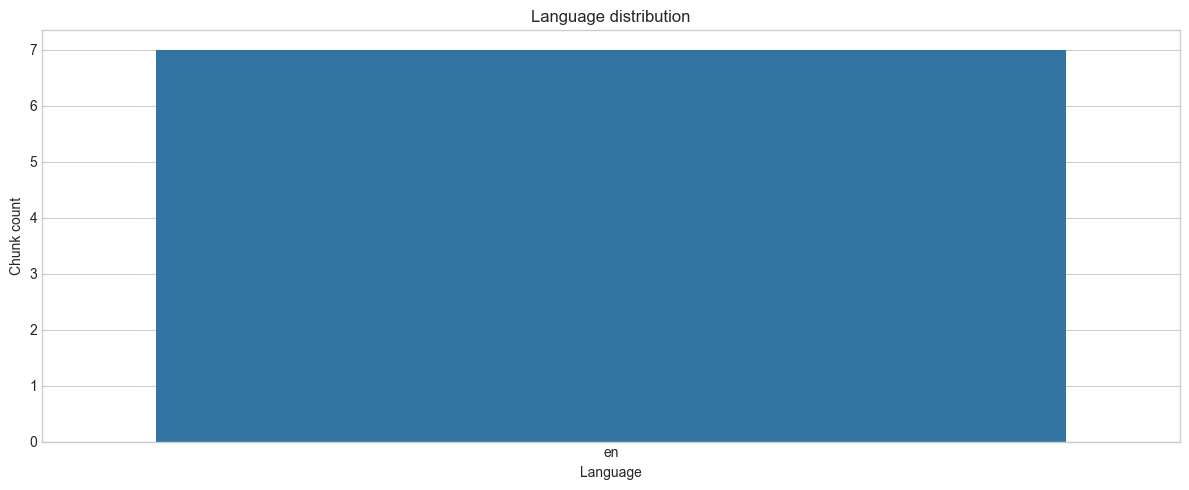

Dominant language: en
The multilingual embedding model is justified when the detected distribution includes multiple languages or mixed-language support content; it also preserves robustness for future non-English sources even when one language dominates this sample.


In [10]:
sample_size = min(500, len(df))
sample = df.sample(n=sample_size, random_state=42) if sample_size else df
languages = []

for text in sample["text"].fillna(""):
    try:
        languages.append(detect(text))
    except Exception:
        languages.append("unknown")

language_counts = pd.Series(languages).value_counts()
plt.figure(figsize=(12, 5))
sns.barplot(x=language_counts.index, y=language_counts.values)
plt.title("Language distribution")
plt.xlabel("Language")
plt.ylabel("Chunk count")
plt.tight_layout()
plt.show()

dominant_language = language_counts.index[0] if not language_counts.empty else "unknown"
print(f"Dominant language: {dominant_language}")
print(
    "The multilingual embedding model is justified when the detected distribution includes "
    "multiple languages or mixed-language support content; it also preserves robustness for "
    "future non-English sources even when one language dominates this sample."
)
